# prepare

In [ ]:
pip install ultralytics

In [ ]:
!mkdir -p /content/rgb/test
!cp -r /path/to/rgb/test/* /content/rgb/test/

In [ ]:
!mkdir -p /content/lwir/test
!cp -r /path/to/lwir/test/* /content/lwir/test/

In [ ]:
!mkdir -p /content/models
!cp -r /path/to/models* /content/models/

# main


In [ ]:
import sys
sys.path.append('/path/to/project')

In [ ]:
from ultralytics import YOLO
import pandas as pd

from functions.pairs import form_pairs, pairs_to_dict, get_lwir_paths
from functions.single_model_predict import predict_images
from functions.ensemble import results_fusion_wr
from functions.helpers import filter_low_confidence, filter_results
from functions.evaluation import evaluate_results
from functions.empty_imgs_verification import verify_empty_rgb_with_lwir

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# Завантаження даних
rgb_test_path = '/content/rgb/test'
lwir_test_path = '/content/lwir/test'
rgb_images_path = rgb_test_path + '/images'
lwir_images_path = lwir_test_path + '/images'

In [ ]:
RGB_IMG_SIZE = (1216, 1936)
LWIR_IMG_SIZE = (512, 640)

THRESHOLD_RGB = 0.381
DISTANCE_THRESHOLD=0.3
CONF_FOV_THRESHOLD=0.25

CONF_RGB = 0.1
CONF_LWIR = 0.5
CONF_FOR_EMPTY = 0.35

IOU_THRESHOLD = 0.4

CLASS_NAMES = ['other', 'PFM-1', 'PMN', 'M6', 'TMA-2', 'TC-3.6']

In [ ]:
# Створення пар зображень 
pairs_df = form_pairs(rgb_images_path, lwir_images_path, 'image_pairs.csv')
pair_dict = pairs_to_dict(pairs_df)

pairs count: 570


In [ ]:
# Завантаження моделей
model_rgb = YOLO("/content/models/models/yolov8n_epochs50_batch16_rgb.pt")
model_lwir = YOLO("/content/models/models/yolo11n_epochs50_batch16_lwir.pt")

In [ ]:
# RGB інференс
rgb_results = predict_images(model_rgb, rgb_images_path, 'predictions_rgb.json', conf_model=CONF_RGB)
print(f"RGB results: {len(rgb_results)}")

RGB results: 1070


In [ ]:
# Фільтрація низького confidence
rgb_lowconfidence = filter_low_confidence(rgb_results, THRESHOLD_RGB)
print(f"Low confidence objects: {len(rgb_lowconfidence)}")

Low confidence objects: 153


In [ ]:
unique_files = {item['file'] for item in rgb_lowconfidence}
print(len(unique_files))


47


In [ ]:
# LWIR інференс тільки для зображень з об'єктами низького confidence
selected_lwir_paths = get_lwir_paths(rgb_lowconfidence, pair_dict, lwir_images_path)
lwir_results = predict_images(model_lwir, selected_lwir_paths, 'predictions_lwir.json', conf_model=CONF_LWIR)
print(f"LWIR results: {len(lwir_results)}")

LWIR results: 55


In [ ]:
# Ансамбль
notanobjectlist = results_fusion_wr(
    rgb_lowconfidence, lwir_results, pair_dict,
    RGB_IMG_SIZE, LWIR_IMG_SIZE,
    iou_threshold=IOU_THRESHOLD, threshold_rgb=THRESHOLD_RGB, distance_threshold=DISTANCE_THRESHOLD,
    conf_fov_threshold=CONF_FOV_THRESHOLD
)
# print(notanobjectlist)
# print(f"Objects to remove: {len(notanobjectlist)}")

In [ ]:
# Фільтрація результатів
filtered_rgb_results = filter_results(rgb_results, notanobjectlist)
print(f"Initial: {len(rgb_results)}, After filtering: {len(filtered_rgb_results)}")

Initial: 1070, After filtering: 1019


In [ ]:
final_results = verify_empty_rgb_with_lwir(filtered_rgb_results, rgb_images_path, lwir_images_path, pair_dict, pairs_df, model_lwir, conf_for_empty=CONF_FOR_EMPTY)

Empty RGB detections: 62
Objects detected on LWIR: 0
Final total detections: 1019


In [ ]:
# Збереження фінальних результатів
df = pd.DataFrame(final_results)
df.to_csv("final_rgblwir_results.csv", index=False)

In [ ]:
# Оцінювання
metrics, matches = evaluate_results(
    "final_rgblwir_results.csv",
    labels_dir='/content/rgb/test/labels',
    img_size=RGB_IMG_SIZE,
    iou_threshold=0.5,
    class_names=CLASS_NAMES
)

metrics_rgb, matches_rgb = evaluate_results(
    "predictions_rgb.json",
    labels_dir='/content/rgb/test/labels',
    img_size=RGB_IMG_SIZE,
    iou_threshold=0.5,
    class_names=CLASS_NAMES
)




metrics:
Precision: 0.9460
Recall:    0.9757
F1-Score:  0.9606
Accuracy:  0.9243

Counts:
True Positives:  964
False Positives: 55
False Negatives: 24

Per-class metrics:
Class: other
   Precision: 0.9309
   Recall: 0.9514
   TP: 431
   FN: 22
   FP: 32
Class: PFM-1
   Precision: 0.9551
   Recall: 0.9967
   TP: 298
   FN: 1
   FP: 14
Class: PMN
   Precision: 1.0000
   Recall: 1.0000
   TP: 90
   FN: 0
   FP: 0
Class: M6
   Precision: 0.9348
   Recall: 1.0000
   TP: 86
   FN: 0
   FP: 6
Class: TMA-2
   Precision: 0.9362
   Recall: 0.9778
   TP: 44
   FN: 1
   FP: 3
Class: TC-3.6
   Precision: 1.0000
   Recall: 1.0000
   TP: 15
   FN: 0
   FP: 0

metrics:
Precision: 0.9009
Recall:    0.9757
F1-Score:  0.9368
Accuracy:  0.8812

Counts:
True Positives:  964
False Positives: 106
False Negatives: 24

Per-class metrics:
Class: other
   Precision: 0.8468
   Recall: 0.9514
   TP: 431
   FN: 22
   FP: 78
Class: PFM-1
   Precision: 0.9521
   Recall: 0.9967
   TP: 298
   FN: 1
   FP: 15
Class: PM

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_overall_metrics_comparison(metrics1, metrics2, labels=("Model 1", "Model 2"), title="Overall metrics comparison"):
    m1 = metrics1['overall']
    m2 = metrics2['overall']

    metrics_names = ["Precision", "Recall", "F1"]
    values1 = [m1['precision'], m1['recall'], m1['f1']]
    values2 = [m2['precision'], m2['recall'], m2['f1']]

    x = np.arange(len(metrics_names))  
    width = 0.35

    fig, ax = plt.subplots(figsize=(7, 5))
    bars1 = ax.bar(x - width/2, values1, width, label=labels[0])
    bars2 = ax.bar(x + width/2, values2, width, label=labels[1])

    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f"{height:.4f}",
                        xy=(bar.get_x() + bar.get_width()/2, height),
                        xytext=(0, 3),  
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels(metrics_names)
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    ax.set_title(title)

    ax.legend(loc='lower right', bbox_to_anchor=(0.7, -0.15), ncol=2)

    plt.tight_layout()
    plt.show()


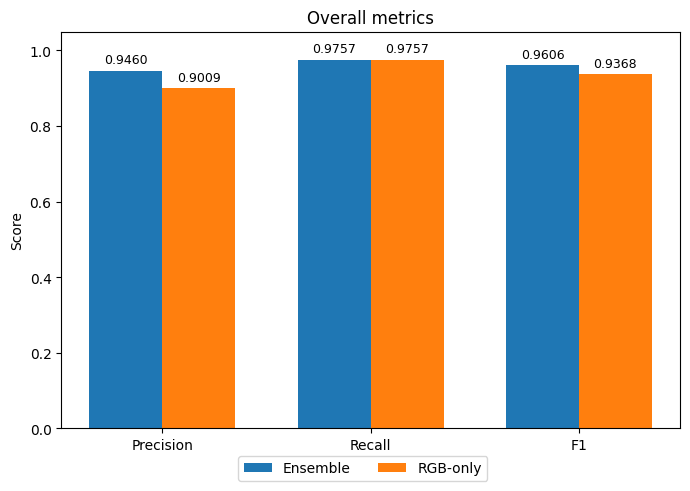

In [ ]:
plot_overall_metrics_comparison(
    metrics, metrics_rgb,
    labels=("Ensemble", "RGB-only"),
    title="Overall metrics"
)
